In [1]:
import datetime as dt

import polars as pl
import os
from spells.config import all_sets
from spells.columns import agg_col
from deq.p1_strategy import all_metrics_analysis
from deq.plot import p1_delta_bar, p1_line_plot
from deq.main import ext, deq_col_specs, live_deq

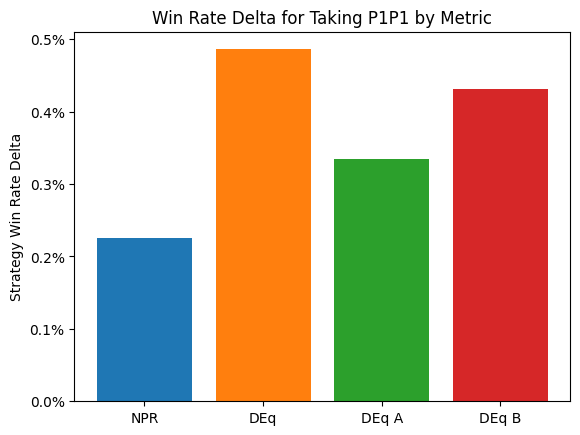

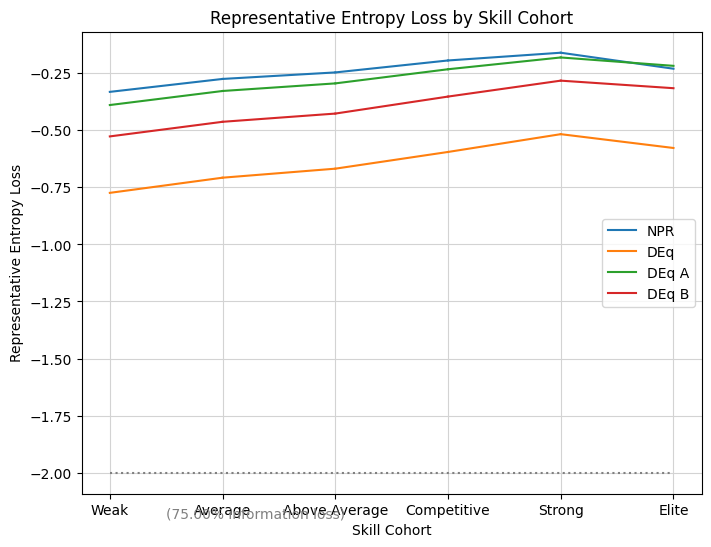

In [8]:
ext = {
    'deq_a': agg_col(100 * pl.col('deq') + pl.col('npr')),
    'deq_b': agg_col(400*pl.col('deq') + pl.col('npr'))
}



metrics = [
    "npr",
    "deq", 
    "deq_a",
    "deq_b"
]


result = all_metrics_analysis(
    sets=["EOE", "FIN", "TDM"], 
    metrics=metrics, 
    results_filter={'lhs': 'format_day', 'op': '>', 'rhs': 2},
    extra_ext=ext
)

p1_delta_bar(result, metrics=metrics)
# p1_line_plot(result, metrics=metrics)
p1_line_plot(result, mode="entropy_loss", metrics=metrics)

In [15]:
result.agg_df


npr_seen_weight,npr_plus_weight,pick_rate_logit_seen_weight,npr_minus_weight,npr_seen_strat_delta,npr_plus_strat_delta,pick_rate_logit_seen_strat_delta,npr_minus_strat_delta
f64,f64,f64,f64,f64,f64,f64,f64
1.6510e6,1.6514e6,1.6496e6,1.6505e6,0.002185,0.002005,0.002138,0.002274


In [16]:
early_format = {"lhs": "format_day", "op": "<", "rhs": 13}
res_d1 = all_metrics_analysis(
    metrics=metrics,
    results_filter=early_format,
    metric_filter={"lhs": "format_day", "op": "<", "rhs": 3},
    deq_days=2,
    extra_ext=ext
)

tag_d1 = "Early format using day 2 metrics"
p1_line_plot(res_d1, mode="wr_delta", metrics=metrics, title_extra=tag_d1)
p1_line_plot(res_d1, mode="entropy_loss", metrics=metrics, title_extra=tag_d1)

NameError: name 'all_metrics_analysis' is not defined

In [4]:
res_d1.agg_df

deq_weight,deq_a_weight,deq_b_weight,deq_strat_delta,deq_a_strat_delta,deq_b_strat_delta
f64,f64,f64,f64,f64,f64
6.8076e6,6.8074e6,6.8071e6,0.006054,0.006064,0.006079


In [13]:
early_top = {"$and": [{"player_cohort": "Top"}, early_format]}
late_format = {"$not": early_format}
tag_mid = "Late format using early top player metrics"
res_mid = all_metrics_analysis(
    metric_filter=early_top, 
    results_filter=late_format, 
    deq_days=12, 
    projection_days=6,
    metrics=metrics, 
    extra_ext=ext
)
p1_line_plot(res_mid, mode="wr_delta", metrics=metrics, title_extra=tag_mid)
p1_line_plot(res_mid, mode="entropy_loss", metrics=metrics, title_extra=tag_mid)
res_mid.agg_df

NameError: name 'early_format' is not defined